In [180]:
import pandas as pd
import numpy as np

In [181]:
courses = pd.read_csv("../data/courses.csv")
students = pd.read_csv("../data/students.csv")
nov = pd.read_csv("../data/reg-month1.csv")
dec = pd.read_csv("../data/reg-month2.csv")

matches = pd.read_csv("../data/matches.csv")
delivery = pd.read_csv("../data/deliveries.csv")

In [182]:
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [183]:
# pd.concat : DataFrame concatenation is a method used to combine two or more DataFrames along a particular axis (rows or columns). It is part of the pandas library in Python and is commonly used for data manipulation and analysis.  
# df.concat
# ignore_index
# df.append : The traditional df.append() method has been completely removed from pandas (as of version 2.0). Using it will result in an """AttributeError"""
# multiindex -> fetch using iloc
# concat dataframes horizontally

In [184]:
nov

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [185]:
dec

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [186]:
regs = pd.concat([nov,dec]) # vertical concatenation of dataframes
regs



,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [187]:
## but the index is repeating  so we tell contact to ignore the index and create a new index for the new dataframe by passing ignore_index = True
regs = pd.concat([nov,dec],ignore_index=True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [188]:
multi = pd.concat([nov,dec],keys=['Nov','Dec'])
# Multiindex DataFrame
multi.sample(5)

student_id  course_id
Dec 9           11          8
    24          11         10
Nov 3           23          4
Dec 21          23          5
    6            7          2

In [189]:
## extracting data from multiindex dataframe
multi.loc[('Dec',4)]

student_id    14
course_id      9
Name: (Dec, 4), dtype: int64

In [190]:
multi.loc[('Dec')].head(2)

,student_id,course_id
0,3,5
1,16,7


In [191]:
multi.loc[('Nov')].head(2)

,student_id,course_id
0,23,1
1,15,5


In [192]:
multi.loc[pd.IndexSlice['Dec', 2:5] , :]


student_id  course_id
Dec 2          12         10
    3          12          1
    4          14          9
    5           7          7

In [193]:
pd.concat([nov,dec],axis=1).tail(7)  ## horizontal concatenation of dataframes

,student_id,course_id,student_id,course_id
21,25.0,1.0,23,5
22,19.0,2.0,14,4
23,25.0,10.0,14,1
24,3.0,3.0,11,10
25,NaN,NaN,42,9
26,NaN,NaN,50,8
27,NaN,NaN,38,1


In [194]:
## for concat if you are vertically stacking using .concat is it necessary to have same columns in both dataframes but if you are horizontally stacking then it is not necessary to have same columns in both dataframes. It will just fill the missing values with NaN

In [195]:
nov.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


#### Merging DataFrames 

In [196]:
regs.tail() ## see we have only students id till 25 and here intentionally we have added  student_id = 42,50,38 for demonstration purpose later in joins 

,student_id,course_id
48,14,1
49,11,10
50,42,9
51,50,8
52,38,1


In [197]:
students.tail()

,student_id,name,partner
20,21,Seema Kota,15
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18
23,24,Radhika Suri,17
24,25,Shashank D’Alia,2


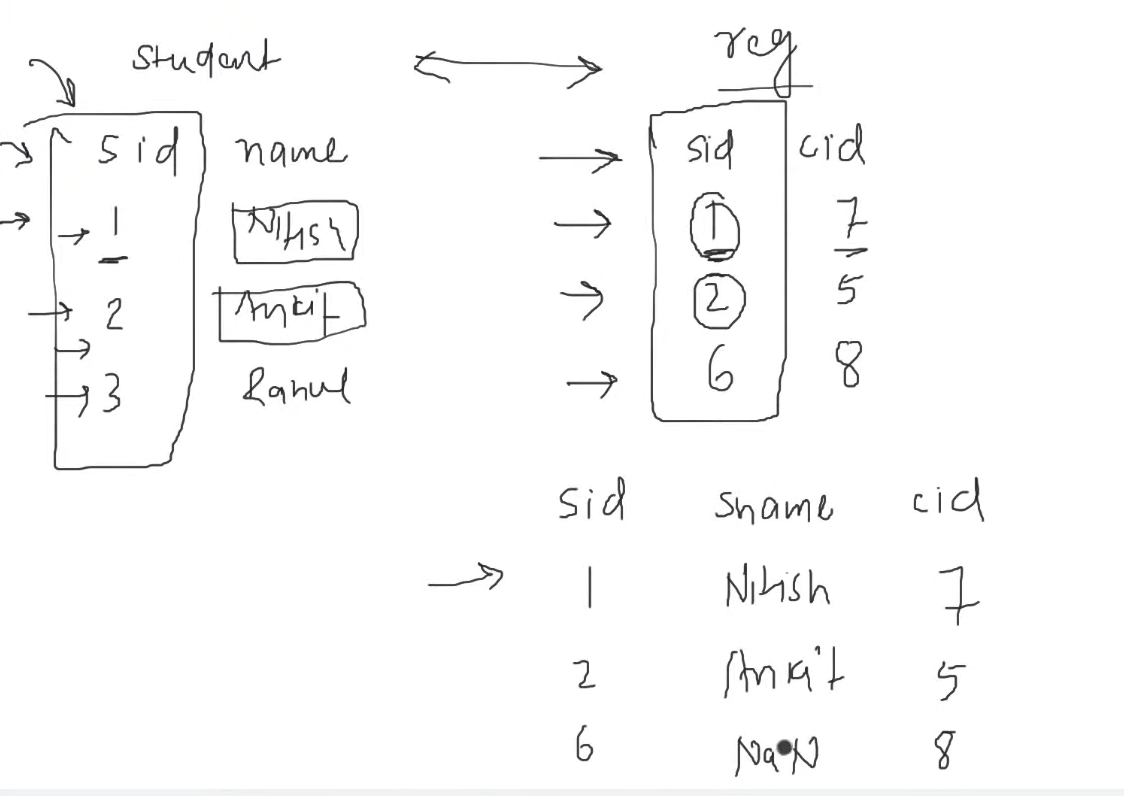

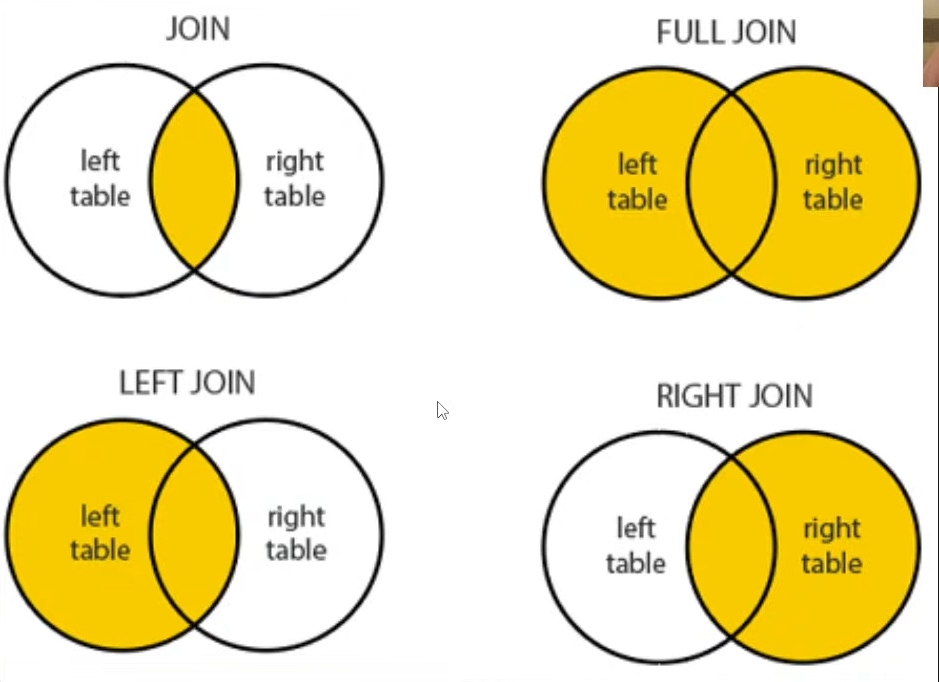

In [198]:
# inner join ==  if you want to keep only the rows that have matching values in both DataFrames, you would use an inner join. This is the default behavior of the merge function in pandas.
students.merge(regs , on = "student_id" , how = "inner")  ## inner join

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [199]:
# left join :  it retains all the left DataFrame's rows and fills in the matching values from the right DataFrame. If there is no match, it fills in with NaN for the right DataFrame's columns.
courses.merge(regs,how='left',on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [200]:
# right join
temp_df = pd.DataFrame({
    'student_id':[26,27,28],
    'name':['Nitish','Ankit','Rahul'],
    'partner':[28,26,17]
})

students = pd.concat([students,temp_df],ignore_index=True)

In [201]:
students.tail()

,student_id,name,partner
23,24,Radhika Suri,17
24,25,Shashank D’Alia,2
25,26,Nitish,28
26,27,Ankit,26
27,28,Rahul,17


In [202]:
students.merge(regs,how='right',on='student_id').tail() # student is left DF and regs is right DF  (show all data of the right DF and matching data of left DF)

,student_id,name,partner,course_id
48,14,Pranab Natarajan,22.0,1
49,11,David Mukhopadhyay,20.0,10
50,42,NaN,NaN,9
51,50,NaN,NaN,8
52,38,NaN,NaN,1


In [203]:
regs.merge(students,how='left',on='student_id').tail() # regs is left DF and students is right DF  ( show all data of the left DF and matching data of right DF)

,student_id,course_id,name,partner
48,14,1,Pranab Natarajan,22.0
49,11,10,David Mukhopadhyay,20.0
50,42,9,NaN,NaN
51,50,8,NaN,NaN
52,38,1,NaN,NaN


In [204]:
# outer join
students.merge(regs,how='outer',on='student_id').tail(10) # shows all data of both DF and fills the missing values with NaN 

,student_id,name,partner,course_id
53,23,Chhavi Lachman,18.0,5.0
54,24,Radhika Suri,17.0,4.0
55,25,Shashank D’Alia,2.0,1.0
56,25,Shashank D’Alia,2.0,10.0
57,26,Nitish,28.0,NaN
58,27,Ankit,26.0,NaN
59,28,Rahul,17.0,NaN
60,38,NaN,NaN,1.0
61,42,NaN,NaN,9.0
62,50,NaN,NaN,8.0


In [205]:
# 1. find total revenue generated
regs.merge(courses, on = "course_id").sort_values(by=["student_id" , "course_id"]).head(8) # default is inner join so we can skip how = "inner"  and we can directly use the column name to get the sum of price column

,student_id,course_id,course_name,price
6,1,1,python,2499
11,1,6,power bi,1899
40,1,9,plotly,699
39,1,10,pyspark,2499
41,2,5,tableau,2499
24,3,3,data analysis,4999
25,3,5,tableau,2499
31,7,2,sql,3499


In [206]:

# ans 
total = regs.merge(courses,how='inner',on='course_id')['price'].sum()
total

154247

In [207]:
# 2. find month by month revenue

# 1 find month by month revenue in a single dataframe using concat vertically and reset the index to get a colum for months and rename it to months 
# 2  usse group on month and sum the price column to get the total revenue month wise
pd.concat([nov,dec],keys=['Nov','Dec']).reset_index().rename(columns={'level_0':'month','level_1':'index'}).head(10)

,month,index,student_id,course_id
0,Nov,0,23,1
1,Nov,1,15,5
2,Nov,2,18,6
3,Nov,3,23,4
4,Nov,4,16,9
5,Nov,5,18,1
6,Nov,6,1,1
7,Nov,7,7,8
8,Nov,8,22,3
9,Nov,9,15,1


In [208]:
# ans
temp_df =pd.concat([nov,dec],keys=['Nov','Dec']).reset_index().rename(columns={'level_0':'month','level_1':'index'})
temp_df.merge(courses,on='course_id').groupby('month')['price'].sum()

month
Dec    65072
Nov    89175
Name: price, dtype: int64

In [209]:
## or 
nov_rev = nov.merge(courses,on='course_id').sum()["price"]
dec_rev = dec.merge(courses,on='course_id').sum()["price"]
print("Total revenue in Nov : ",nov_rev)
print("Total revenue in Dec : ",dec_rev)

Total revenue in Nov :  89175
Total revenue in Dec :  65072


In [210]:
# 3. Print the registration table
# cols -> name -> course -> price
regs.merge(students,on='student_id').merge(courses,on='course_id').head(2)

,student_id,course_id,name,partner,course_name,price
0,23,1,Chhavi Lachman,18,python,2499
1,15,5,Preet Sha,16,tableau,2499


In [211]:
regs.merge(students,on='student_id').merge(courses,on='course_id').head(2)[['name','course_name','price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499


In [212]:
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [213]:
# 4. Plot bar chart for revenue/course

In [214]:
regs.merge(courses , on= 'course_id').sort_values(by = ["student_id" , "course_id"]).head(8)

,student_id,course_id,course_name,price
6,1,1,python,2499
11,1,6,power bi,1899
40,1,9,plotly,699
39,1,10,pyspark,2499
41,2,5,tableau,2499
24,3,3,data analysis,4999
25,3,5,tableau,2499
31,7,2,sql,3499


In [215]:
regs.merge(courses,on='course_id').groupby('course_name')['price'].sum()

course_name
data analysis       24995
machine learning    39996
ms sxcel             7995
pandas               4396
plotly               3495
power bi            11394
pyspark             14994
python              22491
sql                  6998
tableau             17493
Name: price, dtype: int64

<Axes: xlabel='course_name'>

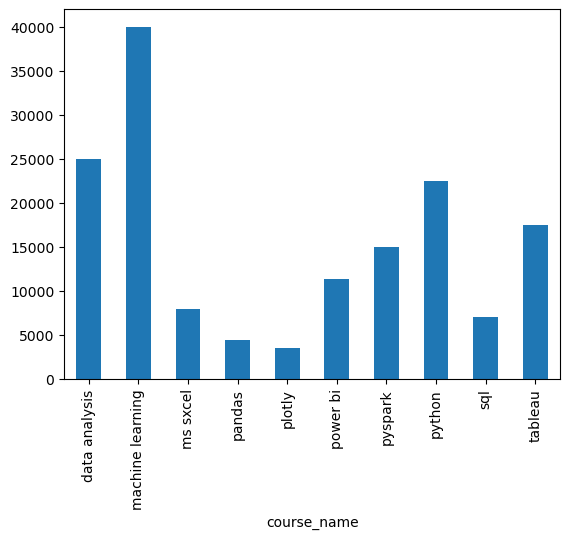

In [216]:

regs.merge(courses,on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

In [217]:
# 5. find students who enrolled in both the months
common_student_id = np.intersect1d(nov['student_id'],dec['student_id'])
common_student_id

array([ 1,  3,  7, 11, 16, 17, 18, 22, 23], dtype=int64)

In [218]:
students[students['student_id'].isin(common_student_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [219]:
# 6. find course that got no enrollment
# courses['course_id']
# regs['course_id']
## set differce using numpy A-B =  the elements that are present in array A but not in array B.

course_id_list = np.setdiff1d(courses['course_id'],regs['course_id'])
courses[courses['course_id'].isin(course_id_list)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [220]:
# 7. find students who did not enroll into any courses
student_id_list = np.setdiff1d(students['student_id'],regs['student_id'])
students[students['student_id'].isin(student_id_list)].shape[0]

(10/28)*100

35.714285714285715

In [221]:
students.head()

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6


In [222]:
# 8. Print student name -> partner name for all enrolled students
# self join
students.merge(students,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [223]:
regs.merge(students,on='student_id').head()

,student_id,course_id,name,partner
0,23,1,Chhavi Lachman,18
1,15,5,Preet Sha,16
2,18,6,Fardeen Mahabir,13
3,23,4,Chhavi Lachman,18
4,16,9,Elias Dodiya,25


In [224]:
# 9. find top 3 students who did most number enrollments
regs_students = regs.merge(students,on='student_id')
top_3_students = regs_students.groupby('student_id').size().sort_values(ascending=False).head(3).index
top_3_students_mask = regs_students['student_id'].isin(top_3_students)
regs_students[top_3_students_mask].sort_values(by='student_id')[ "name"].unique()

array(['Kailash Harjo', 'Tarun Thaker', 'Chhavi Lachman'], dtype=object)

In [225]:
# or 
regs.merge(students , on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3)

student_id  name          
23          Chhavi Lachman    6
7           Tarun Thaker      5
1           Kailash Harjo     4
Name: name, dtype: int64

In [226]:
# 10. find top 3 students who spent most amount of money on courses
regs.merge(students,on='student_id').merge(courses,on='course_id').groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64

In [227]:
# Alternate syntax for merge ## sntax : pd.merge(left_df,right_df,how='inner',on='common_column')  ## inner join
# students.merge(regs)



pd.merge(students,regs,how='inner',on='student_id').head()

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5


In [228]:
# IPL Problems

# find top 3 studiums with highest sixes/match ratio
# find orange cap holder of all the seasons

In [229]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [230]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [231]:
# match_id delivery Data set id represents the id in the matches Data set 

In [ ]:
temp_df = delivery.merge(matches,left_on='match_id',right_on='id')

In [236]:
temp_df.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN


In [240]:
six_df = temp_df[temp_df['batsman_runs'] == 6] # ONLY THE BALLS WHERE BATS MAN SCORED 6 RUNS    

In [256]:
# stadium -> sixes
num_sixes = six_df.groupby('venue')['venue'].count() # uts a series with index as venue and value as number of sixes scored in that stadium
num_sixes.head(5 )

venue
Barabati Stadium               68
Brabourne Stadium             114
Buffalo Park                   27
De Beers Diamond Oval          34
Dr DY Patil Sports Academy    173
Name: venue, dtype: int64

In [255]:
num_matches = matches['venue'].value_counts() ## its a series with index as venue and value as number of matches played in that stadium
num_matches.head(5 )

venue
M Chinnaswamy Stadium                        66
Eden Gardens                                 61
Feroz Shah Kotla                             60
Wankhede Stadium                             57
Rajiv Gandhi International Stadium, Uppal    49
Name: count, dtype: int64

In [ ]:
(num_sixes/num_matches).sort_values(ascending=False).head(10)

Holkar Cricket Stadium                                 17.600000
M Chinnaswamy Stadium                                  13.227273
Sharjah Cricket Stadium                                12.666667
Himachal Pradesh Cricket Association Stadium           12.000000
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium    11.727273
Wankhede Stadium                                       11.526316
De Beers Diamond Oval                                  11.333333
Maharashtra Cricket Association Stadium                11.266667
JSCA International Stadium Complex                     10.857143
Sardar Patel Stadium, Motera                           10.833333
Name: venue, dtype: float64

In [258]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [259]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum()

season  batsman          
2008    A Chopra              42
        A Kumble              13
        A Mishra              37
        A Mukund               0
        A Nehra                3
                            ... 
2017    Washington Sundar      9
        YK Pathan            143
        YS Chahal             13
        Yuvraj Singh         252
        Z Khan                 4
Name: batsman_runs, Length: 1531, dtype: int64

In [260]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(subset=['season'],keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641


In [261]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False)

,season,batsman,batsman_runs
1383,2016,V Kohli,973
1278,2016,DA Warner,848
910,2013,MEK Hussey,733
684,2012,CH Gayle,733
852,2013,CH Gayle,720
...,...,...,...
1467,2017,MM Patel,0
658,2012,AC Blizzard,0
475,2011,AB Dinda,0
1394,2017,AD Nath,0
